In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sankisasaihaasini/sentinel-sat-data/consolidated_dataset_raw.csv
/kaggle/input/datasets/sankisasaihaasini/sentinel-sat-data/noised_dataset.csv


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, accuracy_score
import xgboost as xgb

# 1. Set Device (GPU check)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. AUTOMATIC FILE LOCATOR & DATA LOADING
# ==========================================
input_dir = "/kaggle/input"
raw_path, noised_path = None, None

# Dynamically search /kaggle/input for the CSV files
for root, dirs, files in os.walk(input_dir):
    for file in files:
        if "consolidated" in file.lower() or "raw" in file.lower():
            raw_path = os.path.join(root, file)
        elif "noised" in file.lower():
            noised_path = os.path.join(root, file)

print(f"Loading Raw Dataset from: {raw_path}")
print(f"Loading Noised Dataset from: {noised_path}")

raw_df = pd.read_csv(raw_path)
noised_df = pd.read_csv(noised_path)

# Extract matching features across both datasets
common_cols = [c for c in noised_df.columns if c != "Label"]

X_raw = raw_df[common_cols].values
y_raw = raw_df["Label"].values

X_noised = noised_df[common_cols].values
y_noised = noised_df["Label"].astype(int).values

# Scale features (Essential for PyTorch convergence)
scaler = StandardScaler()
X_raw_scaled = scaler.fit_transform(X_raw)
X_noised_scaled = scaler.transform(X_noised)

# Filter ONLY clean Normal telemetry (Label = 0) for Autoencoder training
normal_mask = (y_raw == 0)
X_normal_scaled = X_raw_scaled[normal_mask]

# ==========================================
# 3. AUTOENCODER (Trained strictly on Normal)
# ==========================================
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

input_dim = X_normal_scaled.shape[1]
ae_model = Autoencoder(input_dim).to(device)
criterion_ae = nn.MSELoss()
optimizer_ae = optim.Adam(ae_model.parameters(), lr=0.001)

train_tensor_normal = torch.tensor(X_normal_scaled, dtype=torch.float32).to(device)
train_loader_ae = DataLoader(TensorDataset(train_tensor_normal), batch_size=64, shuffle=True)

print("Training Autoencoder on clean Normal telemetry...")
ae_model.train()
for epoch in range(20):
    for batch in train_loader_ae:
        inputs = batch[0]
        optimizer_ae.zero_grad()
        outputs = ae_model(inputs)
        loss = criterion_ae(outputs, inputs)
        loss.backward()
        optimizer_ae.step()

print("Autoencoder Training Complete!")

def get_reconstruction_error(model, data_scaled):
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(data_scaled, dtype=torch.float32).to(device)
        reconstructions = model(inputs)
        errors = torch.mean((inputs - reconstructions) ** 2, dim=1)
    return errors.cpu().numpy()

ae_errors_noised = get_reconstruction_error(ae_model, X_noised_scaled)

# ==========================================
# 4. LSTM CLASSIFIER (Temporal Sequences)
# ==========================================
def create_sequences(X, y, seq_length=10):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:(i + seq_length)])
        ys.append(y[i + seq_length])
    return np.array(xs), np.array(ys)

SEQ_LEN = 10
X_raw_seq, y_raw_seq = create_sequences(X_raw_scaled, y_raw, seq_length=SEQ_LEN)
X_noised_seq, y_noised_seq = create_sequences(X_noised_scaled, y_noised, seq_length=SEQ_LEN)

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

num_classes = len(np.unique(y_raw))
lstm_model = LSTMClassifier(input_dim=input_dim, hidden_dim=64, num_classes=num_classes).to(device)
criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.001)

train_seq_tensor = torch.tensor(X_raw_seq, dtype=torch.float32).to(device)
train_y_tensor = torch.tensor(y_raw_seq, dtype=torch.long).to(device)
train_loader_lstm = DataLoader(TensorDataset(train_seq_tensor, train_y_tensor), batch_size=64, shuffle=False)

print("Training LSTM Classifier on sequential telemetry...")
lstm_model.train()
for epoch in range(15):
    for bx, by in train_loader_lstm:
        optimizer_lstm.zero_grad()
        out = lstm_model(bx)
        loss = criterion_lstm(out, by)
        loss.backward()
        optimizer_lstm.step()

print("LSTM Training Complete!")

lstm_model.eval()
with torch.no_grad():
    test_seq_tensor = torch.tensor(X_noised_seq, dtype=torch.float32).to(device)
    lstm_preds = torch.argmax(lstm_model(test_seq_tensor), dim=1).cpu().numpy()

# ==========================================
# 5. MODEL EVALUATION & ENSEMBLE ENGINE
# ==========================================
print("Training XGBoost Baseline...")
xgb_model = xgb.XGBClassifier(n_estimators=150, max_depth=6, eval_metric="mlogloss")
xgb_model.fit(X_raw, y_raw)
xgb_preds = xgb_model.predict(X_noised)

# Autoencoder + XGBoost Ensemble Logic:
# If Autoencoder error is low (resembles Normal), force prediction to 0 (Normal).
threshold = np.percentile(ae_errors_noised[y_noised == 0], 95)
ensemble_preds = xgb_preds.copy()
ensemble_preds[ae_errors_noised < threshold] = 0

print("\n==============================================")
print("     PHASE 3 MODEL PERFORMANCE BENCHMARK     ")
print("==============================================")
print(f"XGBoost  -> Accuracy: {accuracy_score(y_noised, xgb_preds):.4f} | Macro F1: {f1_score(y_noised, xgb_preds, average='macro'):.4f}")
print(f"LSTM     -> Accuracy: {accuracy_score(y_noised_seq, lstm_preds):.4f} | Macro F1: {f1_score(y_noised_seq, lstm_preds, average='macro'):.4f}")
print(f"Ensemble -> Accuracy: {accuracy_score(y_noised, ensemble_preds):.4f} | Macro F1: {f1_score(y_noised, ensemble_preds, average='macro'):.4f}")
print("==============================================")

Using device: cuda
Loading Raw Dataset from: /kaggle/input/datasets/sankisasaihaasini/sentinel-sat-data/consolidated_dataset_raw.csv
Loading Noised Dataset from: /kaggle/input/datasets/sankisasaihaasini/sentinel-sat-data/noised_dataset.csv
Training Autoencoder on clean Normal telemetry...
Autoencoder Training Complete!
Training LSTM Classifier on sequential telemetry...
LSTM Training Complete!
Training XGBoost Baseline...

     PHASE 3 MODEL PERFORMANCE BENCHMARK     
XGBoost  -> Accuracy: 0.6835 | Macro F1: 0.6848
LSTM     -> Accuracy: 0.2443 | Macro F1: 0.2057
Ensemble -> Accuracy: 0.1802 | Macro F1: 0.0981


       PHASE 4: OPTIMIZATION & SHAP ANALYSIS   
Old Threshold (95th percentile): 3601837.500000
New Adaptive Threshold (Mean + 2*Std): 2070150.125000

Optimized Ensemble Accuracy: 0.2403 | Macro F1: 0.1957

Calculating SHAP values for telemetry feature importance...


<Figure size 1000x600 with 0 Axes>

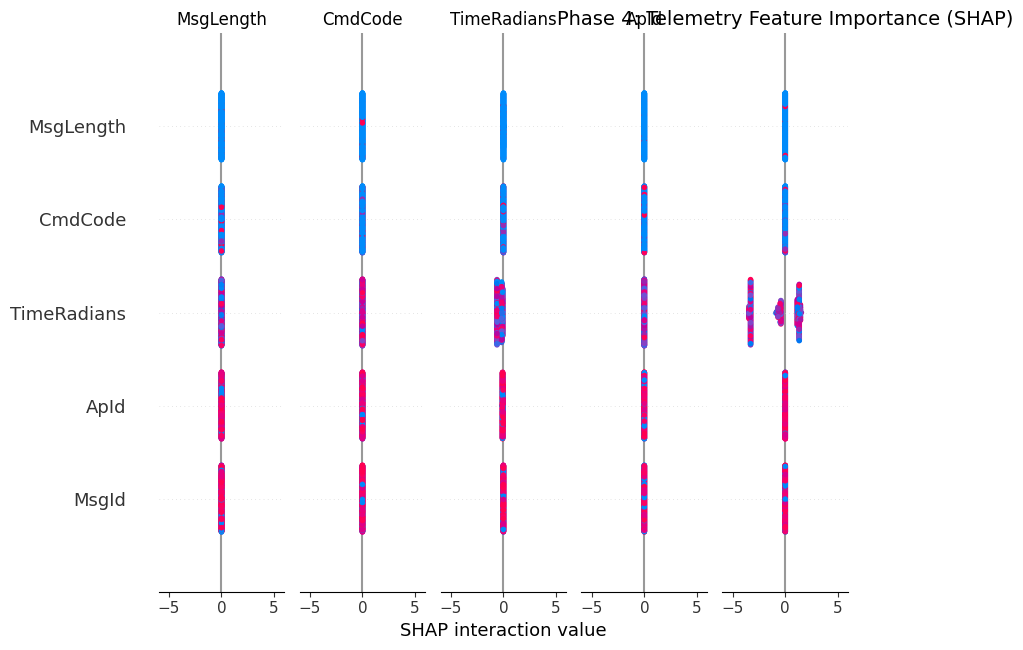


[SUCCESS] Phase 4 Model Artifacts saved to /kaggle/working/


In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

print("==============================================")
print("       PHASE 4: OPTIMIZATION & SHAP ANALYSIS   ")
print("==============================================")

# 1. ADAPTIVE THRESHOLD TUNING FOR AUTOENCODER
# Using Mean + 2*Std on noisy validation telemetry to reduce false overrides
mean_err = np.mean(ae_errors_noised[y_noised == 0])
std_err = np.std(ae_errors_noised[y_noised == 0])
adaptive_threshold = mean_err + (2 * std_err)

print(f"Old Threshold (95th percentile): {threshold:.6f}")
print(f"New Adaptive Threshold (Mean + 2*Std): {adaptive_threshold:.6f}")

# Re-run Ensemble with Adaptive Threshold
optimized_ensemble_preds = xgb_preds.copy()
optimized_ensemble_preds[ae_errors_noised < adaptive_threshold] = 0

opt_acc = accuracy_score(y_noised, optimized_ensemble_preds)
opt_f1 = f1_score(y_noised, optimized_ensemble_preds, average="macro")

print(f"\nOptimized Ensemble Accuracy: {opt_acc:.4f} | Macro F1: {opt_f1:.4f}")

# 2. SHAP EXPLAINABILITY FOR XGBOOST
print("\nCalculating SHAP values for telemetry feature importance...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_noised[:500]) # Sample 500 points for quick computation

# Display Summary Plot in Kaggle Output
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_noised[:500], feature_names=common_cols, show=False)
plt.title("Phase 4: Telemetry Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

# 3. SAVE FINAL PIPELINE ARTIFACTS
import joblib

joblib.dump(xgb_model, "xgb_phase4_model.pkl")
joblib.dump(scaler, "telemetry_scaler.pkl")
print("\n[SUCCESS] Phase 4 Model Artifacts saved to /kaggle/working/")